# Стохастический градиентный и координатный спуски

Для каждого задания указано количество баллов (если они оцениваются отдельно) + 1 балл за аккуратное и полное выполнение всего задания

## Загрузка и подготовка данных

**Загрузите уже знакомый вам файл *Advertising.csv* как объект DataFrame.** 

In [1]:
#ваш код
# Библиотеки
import pandas as pd
import numpy as np

# Загрузка данных
data = pd.read_csv('data/Advertising.csv', index_col=0)
data.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


**Проверьте, есть ли в данных пропуски и, если они есть - удалите их**

In [2]:
#ваш код
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


In [3]:
#ваш код 
missing_data = data.isnull().sum()
print('Количество пропущенных значений в данных:', missing_data.sum())

Количество пропущенных значений в данных: 0


**Преобразуйте ваши признаки в массивы NumPy и разделите их на переменные X (предикторы) и y(целевая переменная)** 

In [4]:
#ваш код 
X = data.drop('sales', axis=1).to_numpy()
y = data['sales'].to_numpy()

## Координатный спуск (3 балла)

**Добавим единичный столбец для того, чтобы у нас был свободный коэффициент в уравнении регрессии:**

In [5]:
import numpy as np

X = np.hstack([np.ones(X.shape[0]).reshape(-1, 1), X])
y = y.reshape(-1, 1)
print(X.shape, y.shape)

(200, 4) (200, 1)


**Нормализуем данные: обычно это необходимо для корректной работы алгоритма**

In [6]:
X = X / np.sqrt(np.sum(np.square(X), axis=0))

**Реализуйте алгоритм координатного спуска:** (3 балла)

Ниже приведен алгоритм координатного спуска для случая нормализованных данных:

**Задано:**

* $X=(x_{ij})$ - матрица наблюдений, размерностью $dim(X)=(m, n)$
* $N=1000$ - количество итераций

**Примечание:** *1000 итераций здесь указаны для этого задания, на самом деле их может быть намного больше, нет детерменированного значения.*

**Алгоритм (математическая запись):**
* Создать нулевой вектор параметров $w_0=(0, 0,..., 0)^T$
* Для всех $t=1, 2, ..., N$ итераций:
    * Для всех $k = 1, 2,..., n$:
        * Фиксируем значение всех признаков, кроме $k$-ого и вычисляем прогноз модели линейной регрессии.Для этого исключаем признак $k$-ый из данных и $w_j$ из параметров при построении прогноза.
        Математически это можно записать следующим образом:

        $$h_i = \sum_{j=1}^{k-1} x_{ij}w_{j} + \sum_{j=k+1}^{n} x_{ij}w_j $$

        **Примечание:**
        
        *Обратите, что в данной записи текущий признак под номером $k$ не участвует в сумме.Сравните эту запись с классической записью прогноза линейной регрессии в случае нормированных данных (когда участвуют все признаки):*

        $$h_i = \sum_{j=1}^{n} x_{ij}w_{j}$$
        
        * Вычисляем новое значение параметра $k$-ого коэффициента: 
        $$w_k = \sum_{i=1}^{m} x_{ik} (y_i - h_i) = x_k^T(y-h) $$

    * Вычисляем значение функции потерь и сохраняем в историю изменения функции потерь (В оценке функции потерь участвуют все признаки):
        $$\hat{y_i} = \sum_{j=1}^{n}x_{ij}w_j$$
        $$Loss_t = \frac{1}{n} \sum_{i=1}^{m}(y_i-\hat{y_i})^2$$
        
        или в векторном виде:
        
        $$\hat{y} = Xw$$
        $$Loss_t = \frac{1}{n}(y-\hat{y})^T(y-\hat{y})$$
    



**Алгоритм (псевдокод):**
```python

num_iters = #количество итераций
m = # количество строк в матрице X
n = # количество столбцов в матрице X
w = #вектор размера nx1, состояющий из нулей

for i in range(num_iters):
    for k in range(n):
        # Вычисляем прогноз без k-ого фактора
        h = (X[:,0:k] @ w[0:k]) + (X[:,k+1:] @ w[k+1:])
        # Обновляем новое значение k-ого коэффициента
        w[k] =  (X[:,k].T @ (y - h))
        # Вычисляем функцию потерь
        cost = sum(((X @ w) - y) ** 2)/(len(y))

```

Вам необходимо реализовать координатный спуск, и вывести веса в модели линейной регрессии.

In [7]:
# ваш код
num_iters = 1000 #количество итераций
m = X.shape[0] # количество строк в матрице X
n = X.shape[1] # количество столбцов в матрице X
w = np.zeros((n, 1)) #вектор размера nx1, состояющий из нулей

# Для хранения истории потерь
loss_history = []
# Условие остановки
epsilon = 1e-8

for i in range(num_iters):
    w_old = w.copy()
    for k in range(n):
        # Вычисляем прогноз без k-ого фактора
        h = (X[:,0:k] @ w[0:k]) + (X[:,k+1:] @ w[k+1:])
        # Обновляем новое значение k-ого коэффициента
        w[k] =  (X[:,k].T @ (y - h))
    # Вычисляем функцию потерь после обновления всех весов
    y_pred = X @ w
    cost = np.mean((y_pred - y) ** 2)
    loss_history.append(cost)

    # Условие остановки
    if np.linalg.norm(w - w_old) < epsilon:
        break

print("Веса:", ', '.join(f"{x:.6f}" for x in w.flatten()))

Веса: 41.562172, 110.131442, 73.528606, -0.550064


Сравните результаты с реализацией линейной регрессии из библиотеки sklearn:

In [8]:
from sklearn.linear_model import LinearRegression
 
model = LinearRegression(fit_intercept=False)
model.fit(X, y)
 
print(model.coef_.round(6))

[[ 41.562172 110.131442  73.528606  -0.550064]]


Если вы все сделали верно, они должны практически совпасть!

**Вывод**: Коэффициенты полученные в цикле с точностью до 6 знаков после запятой совпадают с коэффициентами полученные в классе LinearRegression. Соответственно можно сделать вывод, что алгоритм составлен верно.

## Стохастический градиентный спуск (6 баллов)

**Отмасштабируйте столбцы исходной матрицы *X* (которую мы не нормализовали еще!). Для того, чтобы это сделать, надо вычесть из каждого значения среднее и разделить на стандартное отклонение** (0.5 баллов)

In [9]:
#ваш код
X = data.drop('sales', axis=1)
X = (X - X.mean()) / X.std()
X = X.to_numpy()

**Добавим единичный столбец**

In [10]:
X = np.hstack([np.ones(X.shape[0]).reshape(-1, 1), X])

**Создайте функцию mse_error для вычисления среднеквадратичной ошибки, принимающую два аргумента: реальные значения и предсказывающие, и возвращающую значение mse** (0.5 балла)

In [11]:
#ваш код
def mse_error(y, y_pred):
    """Функция вычисляющая среднеквадратическая ошибка (MSE)
    Args:
        y (array): реальные значения функции
        y_pred (array): предсказанные значения функции
    Returns:
        float: среднеквадратическая ошибка MSE
    """
    mse = ((y - y_pred)**2).mean()
    return mse

**Сделайте наивный прогноз: предскажите продажи средним значением. После этого рассчитайте среднеквадратичную ошибку для этого прогноза** (0.5 балла)

In [12]:
#ваш код
# Вычисляем среднее значение y
mean_y = sum(y) / len(y)
# Создаем наивный прогноз (все элементы = среднему)
y_naive = [mean_y] * len(y)
print('Среднеквадратическая ошибка наивного прогноза - MSE =', mse_error(y, y_naive).round(5))

Среднеквадратическая ошибка наивного прогноза - MSE = 27.08574


**Создайте функцию *lin_pred*, которая может по матрице предикторов *X* и вектору весов линейной модели *w* получить вектор прогнозов** (0.5 балла)

In [13]:
#ваш код
def lin_pred(X, w):
    """Функция вычисляющая предсказания
    Args:
        X (array): матрица предикторов
        w (array): веча линейной модели
    Returns:
        array: вектор прогнозов
    """
    y_pred = X@w
    return y_pred

**Создайте функцию *stoch_grad_step* для реализации шага стохастического градиентного спуска. (1.5 балла) 
Функция должна принимать на вход следующие аргументы:**
* матрицу *X*
* вектора *y* и *w*
* число *train_ind* - индекс объекта обучающей выборки (строки матрицы *X*), по которому считается изменение весов
* число *$\eta$* (eta) - шаг градиентного спуска

Результатом будет вектор обновленных весов

Шаг для стохастического градиентного спуска выглядит следующим образом:

$$\Large w_j \leftarrow w_j - \frac{2\eta}{\ell} \sum_{i=1}^\ell{{x_{ij}((w_0 + w_1x_{i1} + w_2x_{i2} +  w_3x_{i3}) - y_i)}}$$

Для того, чтобы написать функцию, нужно сделать следующее:
    
*  посчитать направление изменения: умножить объект обучающей выборки на 2 и на разницу между предсказанным значением и реальным, а потом поделить на количество элементов в выборке.
* вернуть разницу между вектором весов и направлением изменения, умноженным на шаг градиентного спуска

In [14]:
#ваш код
def stoch_grad_step(X, y, w, train_ind, eta):
    """ Функция реализующая шаг стохастического градиентного спуска.
    
    Args:
        X (array): матрица предикторов
        y (array): вектор реальных значений
        w (array): вектор весов линейной модели
        train_ind (int): индекс объекта обучающей выборки
        eta (float): шаг градиентного спуска
    
    Returns:
        array: вектор обновленных весов
    """
    direction = (2 * X[train_ind] * (lin_pred(X[train_ind], w) - y[train_ind])) / len(y)
    w_new = w - eta * direction.reshape(-1, 1)
    return w_new

**Создайте функцию *stochastic_gradient_descent*, для реализации стохастического градиентного спуска (2.5 балла)**

**Функция принимает на вход следующие аргументы:**
- Матрицу признаков X
- Целевую переменнную
- Изначальную точку (веса модели)
- Параметр, определяющий темп обучения
- Максимальное число итераций
- Евклидово расстояние между векторами весов на соседних итерациях градиентного спуска,при котором алгоритм прекращает работу 

**На каждой итерации в вектор (список) должно записываться текущее значение среднеквадратичной ошибки. Функция должна возвращать вектор весов $w$, а также вектор (список) ошибок.**

Алгоритм сследующий:
    
* Инициализируйте расстояние между векторами весов на соседних итерациях большим числом (можно бесконечностью)
* Создайте пустой список для фиксации ошибок
* Создайте счетчик итераций
* Реализуйте оновной цикл обучения пока расстояние между векторами весов больше того, при котором надо прекратить работу (когда расстояния станут слишком маленькими - значит, мы застряли в одном месте) и количество итераций меньше максимально разрешенного: сгенерируйте случайный индекс, запишите текущую ошибку в вектор ошибок, запишите в переменную текущий шаг стохастического спуска с использованием функции, написанной ранее. Далее рассчитайте текущее расстояние между векторами весов и прибавьте к счетчику итераций 1.
* Верните вектор весов и вектор ошибок

In [15]:
# ваш код
def stochastic_gradient_descent (X, y, w, eta, max_iter, epsilon):
    """Функция реализующая стохастический градиентный спуск

    Args:
        X (array): матрица предикторов
        y (array): вектор реальных значений
        w (array): вектор весов линейной модели
        eta (float): шаг градиентного спуска
        max_iter (int): максимальное число итераций
        epsilon (float): Евклидово расстояние между векторами весов на соседних
        итерациях градиентного спуска,при котором алгоритм прекращает работу

    Returns:
        array, list: вектор весов и список ошибок
    """
    distance = float('inf')                          # расстояние между векторами
    errors = []                                      # список фиксации ошибок
    counter = 0                                      # счетчик

    # Пока расстояние между векторами больше заданного ограничения
    # и пока счетчик не превысил максимум заданных итераций
    while distance > epsilon and max_iter > counter:
        random_idx = np.random.randint(0, len(y))    # генерация случайного индекса
        y_pred = lin_pred(X, w)                      # делаю предсказание с стартовой точки
        mse = mse_error(y, y_pred)                   # вычисляю MSE
        errors.append(mse)                           # вношу в список

        # определяю новый вектор весов
        w_new = stoch_grad_step(X, y, w, random_idx, eta)
        # обновляю дистанцию
        distance = np.linalg.norm(w - w_new)
        # обновляю вектор и счетчик
        w = w_new
        counter += 1
    return w, errors

 **Запустите $10^5$ итераций стохастического градиентного спуска. Укажите вектор начальных весов, состоящий из нулей. Можете поэкспериментировать с параметром, отвечающим за темп обучения.**

**Постройте график зависимости ошибки от номера итерации**

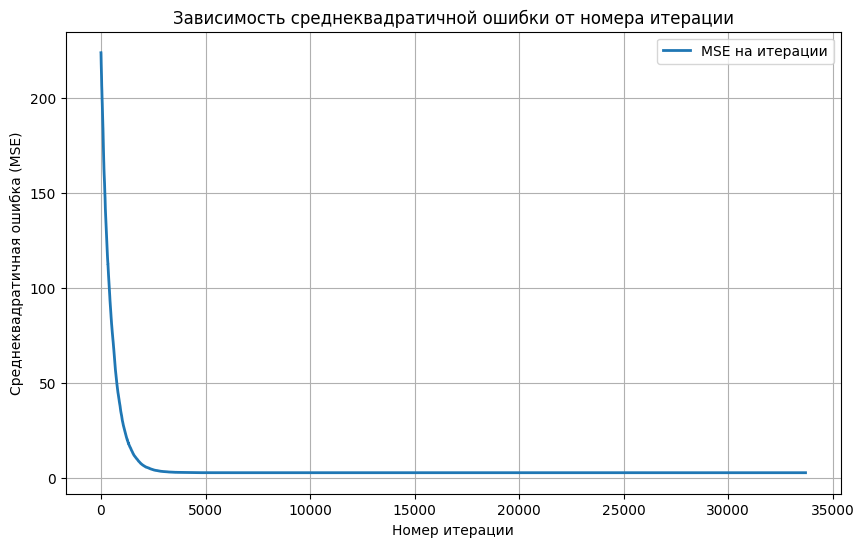

In [16]:
# ваш код
w = np.zeros((X.shape[1], 1))
eta = 0.1
max_iter = 10**5
epsilon = 1e-7
w, errors = stochastic_gradient_descent(X, y, w, eta, max_iter, epsilon)

import matplotlib.pyplot as plt

# Построение графика
plt.figure(figsize=(10, 6)) # Установка размера графика
plt.plot(errors, lw=2, label='MSE на итерации')
plt.title('Зависимость среднеквадратичной ошибки от номера итерации')
plt.xlabel('Номер итерации')
plt.ylabel('Среднеквадратичная ошибка (MSE)')
plt.legend()
plt.grid()
plt.show();

**Выведите вектор весов, к которому сошелся метод.**

In [17]:
# ваш код
print("Веса:", ', '.join(f"{x:.6f}" for x in w.flatten()))

Веса: 14.031241, 3.981242, 2.758158, -0.047924


**Выведите среднеквадратичную ошибку на последней итерации.**

In [18]:
# ваш код
print('Среднеквадратическая ошибка стохастического градиентного спуска - MSE =', errors[-1].round(5))

Среднеквадратическая ошибка стохастического градиентного спуска - MSE = 2.78956


**Вывод:** Стохастический градиентный спуск помог снизить среднеквадратическую ошибку MSE до 2.78956 (наивный методом мы получили MSE=27.08574). Наилучший баланс скорости и точности модель показывает при значениях eta = 0.1 и epsilon = 1e-7.